In [ ]:
import sys
import os
import pandas as pd
sys.path.append("src/")   

from data_utils import (
    check_missing_and_corrupted, compute_hash, find_duplicates_within,
    find_cross_split_leaks, remove_leaked_ids, class_distribution_report,
    plot_class_distribution , compute_blurriness,
    get_blur_data,  
    show_samples_per_class, save_figure
)

root_dir= "archive"

#list all files in the directory
for i in os.listdir(root_dir):
    print("  ",i)

#load csv labels
train_casv_path=os.path.join(root_dir,"train.csv")
df= pd.read_csv(train_casv_path)

print("Dataframe shape:", df.shape)
print("Dataframe columns:", df.columns)
print(df.head())

print("Datatypes:", df.dtypes)

print("any missing values:", df.isnull().sum())



   test.csv
   test_images
   train.csv
   train_images
   valid.csv
   val_images
Dataframe shape: (2930, 2)
Dataframe columns: Index(['id_code', 'diagnosis'], dtype='str')
        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0
Datatypes: id_code        str
diagnosis    int64
dtype: object
any missing values: id_code      0
diagnosis    0
dtype: int64


Observation: 
Dataset provided is already split in train/valid/test
no missing values present 


In [ ]:
train_images_dir = os.path.join(root_dir, "train_images/train_images")
print("Folder path:", os.path.abspath(train_images_dir))
print("First 10 files in folder:")
print(os.listdir(train_images_dir)[:10])

Folder path: c:\Users\Yuvika Agrawal\Desktop\Workings\opencv\Diabetic_Retinopathy\archive\train_images\train_images
First 10 files in folder:
['1ae8c165fd53.png', '1b329a127307.png', '1b32e1d775ea.png', '1b3647865779.png', '1b398c0494d1.png', '1b4625877527.png', '1b495ac025b7.png', '1b862fb6f65d.png', '1b8701231c8f.png', '1b8ad0afe9fb.png']


In [ ]:
missing_files, corrupted_files = check_missing_and_corrupted(df, train_images_dir)
print("Total files in dataframe:", len(df))
print(f"Missing: {len(missing_files)}, Corrupted: {len(corrupted_files)}")

Total files in dataframe: 2930
Missing: 0, Corrupted: 0


All images are readable and verified , Data Integrity confirmed, each image name has a unique id therefore to check for duplicacy, image content need to be used . 

In [28]:
#Duplicate check (Standard Lightweight Hashing)

hashes, duplicate_files = find_duplicates_within(df, train_images_dir)
print("Total images in dataframe:", len(df))
print("Duplicate files:", len(duplicate_files))

if duplicate_files:
    print("Sample duplicates:", duplicate_files[:5])



Total images in dataframe: 2930
Duplicate files: 79
Sample duplicates: [('2b21d293fdf2', '2a3a1ed1c285'), ('35aa7f5c2ec0', '1c4d87baaffc'), ('36ec36c301c1', '26e231747848'), ('38fe9f854046', '1dfbede13143'), ('3c53198519f7', '1c5e6cdc7ee1')]


two different id_code 's pointing to identical images : similar photo logged twice , it is still considerable within train set but not if one duplicates is in test or valid dataset, leaking data information.

In [31]:
valid_df = pd.read_csv(os.path.join(root_dir, "valid.csv"))
valid_images_dir = os.path.join(root_dir, "val_images/val_images") 

test_df = pd.read_csv(os.path.join(root_dir, "test.csv"))
test_images_dir = os.path.join(root_dir, "test_images/test_images") 

valid_leaks=find_cross_split_leaks( valid_df, valid_images_dir, hashes)
test_leaks=find_cross_split_leaks(test_df, test_images_dir, hashes)

print(f"Total valid images: {len(valid_df)}")
print(f"Total test images: {len(test_df)}")
print(f"Train-Valid leaks: {len(valid_leaks)}")
print(f"Train-Test leaks: {len(test_leaks)}")

if valid_leaks:
    print("Sample valid leaks:", valid_leaks[:5])
if test_leaks:
    print("Sample test leaks:", test_leaks[:5])

Total valid images: 366
Total test images: 366
Train-Valid leaks: 22
Train-Test leaks: 22
Sample valid leaks: [('00cb6555d108', 'ca25745942b0'), ('012a242ac6ff', '1f07dae3cadb'), ('0161338f53cc', 'cac40227d3b2'), ('026dcd9af143', '98e8adcf085c'), ('034cb07a550f', 'c8d2d32f7f29')]
Sample test leaks: [('e4e343eaae2a', '43fb6eda9b97'), ('e740af6ac6ea', '98f7136d2e7a'), ('e76a9cbb2a8c', 'bb7e0a2544cd'), ('e7a7187066ad', 'ce887b196c23'), ('ea05c22d92e9', 'ca0f1a17c8e5')]


Both valid and test dataset have an identical duplicate in the training set , meaning leaked images present

In [32]:
# Remove leaked train images from the original dataframe
df_clean, leaked_train_ids = remove_leaked_ids(df, [valid_leaks, test_leaks])

print(f"Total unique leaked train images: {len(leaked_train_ids)}")
print(f"Original train dataframe shape: {df.shape}")
print(f"Cleaned train dataframe shape: {df_clean.shape}")

Total unique leaked train images: 44
Original train dataframe shape: (2930, 2)
Cleaned train dataframe shape: (2886, 2)


In [17]:
#Class distribution before and after cleaning

print("Original class distribution:")
print(df['diagnosis'].value_counts().sort_index())

print("\nCleaned class distribution:")
print(df_clean['diagnosis'].value_counts().sort_index())

Original class distribution:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64

Cleaned class distribution:
diagnosis
0    1432
1     291
2     784
3     152
4     227
Name: count, dtype: int64


In [ ]:
# Class distribution, percentage, and imbalance ratio 
distribution_report = class_distribution_report(df_clean)
print(distribution_report)

           count  percentage  imbalance_ratio
diagnosis                                    
0           1432       49.62             1.00
1            291       10.08             4.92
2            784       27.17             1.83
3            152        5.27             9.42
4            227        7.87             6.31


Grade 0 dominates , Grade 3 is the rarest almost 10x rarer than grade 0 

Figure saved to: ./outputs/figures/class_distribution.png


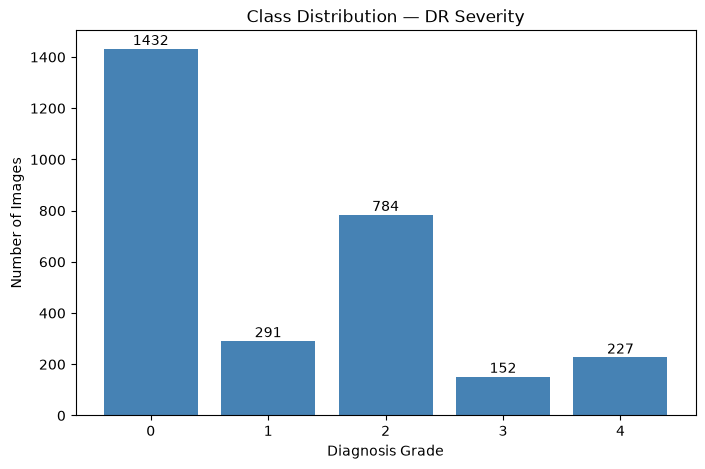

In [34]:
fig= plot_class_distribution(df_clean, title="Class Distribution — DR Severity",
                         save_path="./outputs/figures/class_distribution.png")

0 → No DR
1 → Mild
2 → Moderate
3 → Severe
4 → Proliferative DR

Figure saved to: ./outputs/figures/class_samples.png


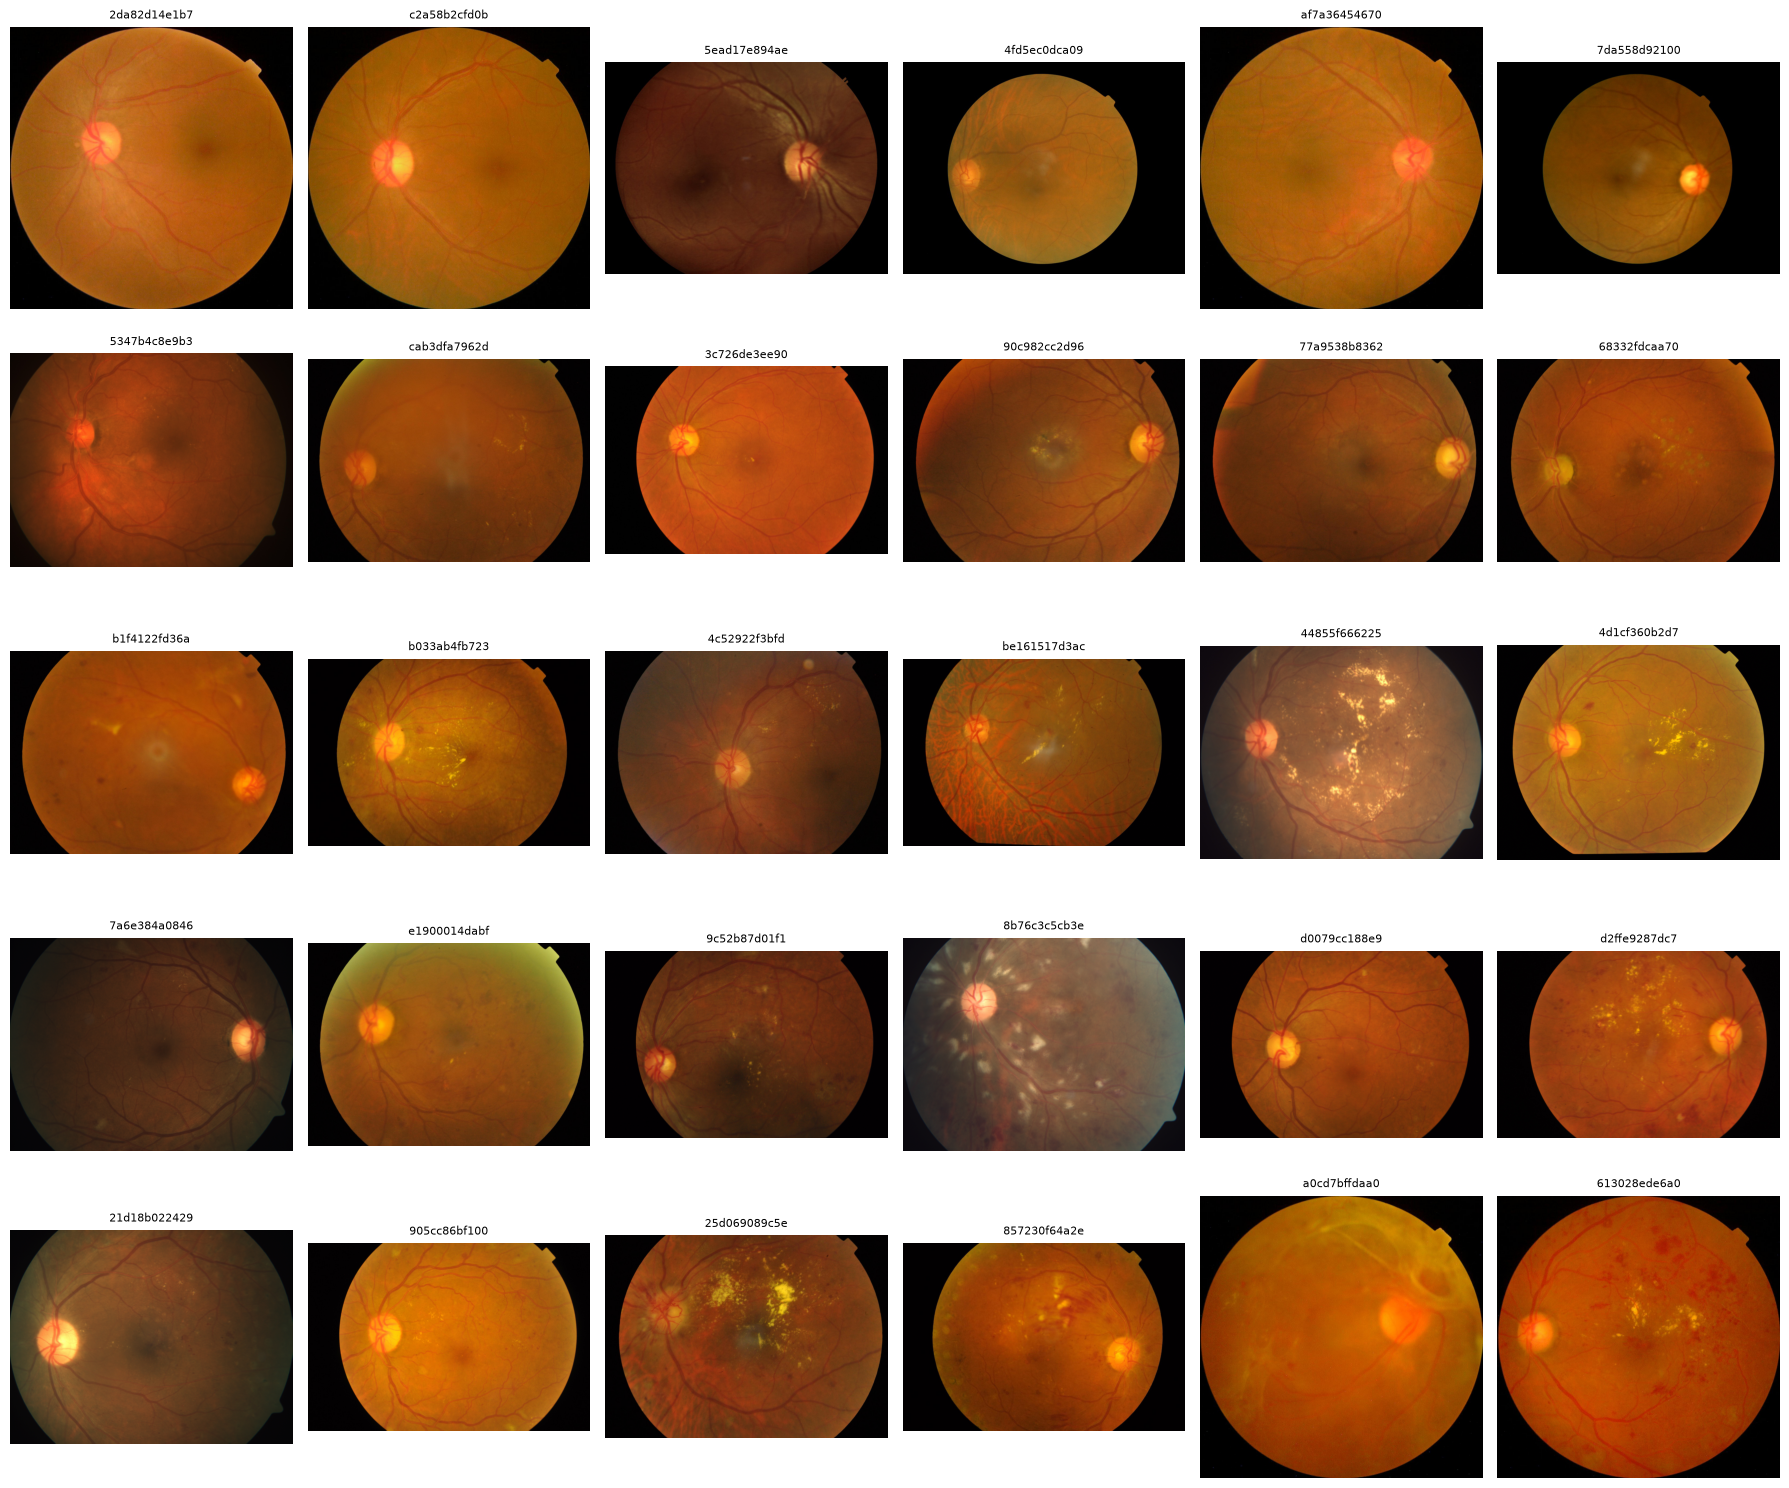

In [35]:
fig = show_samples_per_class(
    df_clean, train_images_dir, n_per_class=6,
    save_path="./outputs/figures/class_samples.png"
)

Observations :
Border and cropping inconsistency 
brightness and sharpness variance in all gardes 
macula seems less visible in severe DR due to hemorrhages (hypothetical)
garde 0 images appear much yellower than the rest images (need to be tested)

In [14]:
#resolution and aspect ratio analysis

import numpy as np

widths, heights, channels = [], [], []

sample_df = df_clean.sample(300, random_state=42)  # random 300 

for img_id in sample_df['id_code']:
    img_path = os.path.join(train_images_dir, img_id + ".png")
    img = Image.open(img_path)
    w, h = img.size
    widths.append(w)
    heights.append(h)
    channels.append(len(img.getbands()))  

print("Width  -> min:", min(widths), "max:", max(widths), "mean:", round(np.mean(widths)))
print("Height -> min:", min(heights), "max:", max(heights), "mean:", round(np.mean(heights)))
print("Unique channel counts found:", set(channels))

aspect_ratios = [w/h for w, h in zip(widths, heights)]
print("Aspect ratio -> min:", round(min(aspect_ratios),2), "max:", round(max(aspect_ratios),2))

Width  -> min: 819 max: 4288 mean: 1970
Height -> min: 614 max: 2848 mean: 1505
Unique channel counts found: {3}
Aspect ratio -> min: 1.0 max: 1.51


Big resolution range = resizing needed = removing a lot of details from the larger cropped images 

aspect ratio = ~1 (images are squarish) = ~1.51 (images rectangular), resizing it to a square can stretch/distort the rectangular ones 

Quantifying Blur (Laplacian, edge detector variance)

--- Mean Blur Score per Class across Splits ---
split           Test      Train      Valid
diagnosis                                 
0          36.416648  37.012014  33.413462
1          10.669555  14.251384  11.053708
2          13.634827  13.069698  14.962290
3          18.835922  13.908502   9.844848
4          12.725424  15.361192  13.026374
Figure saved to: ./outputs/figures/blur_by_class.png


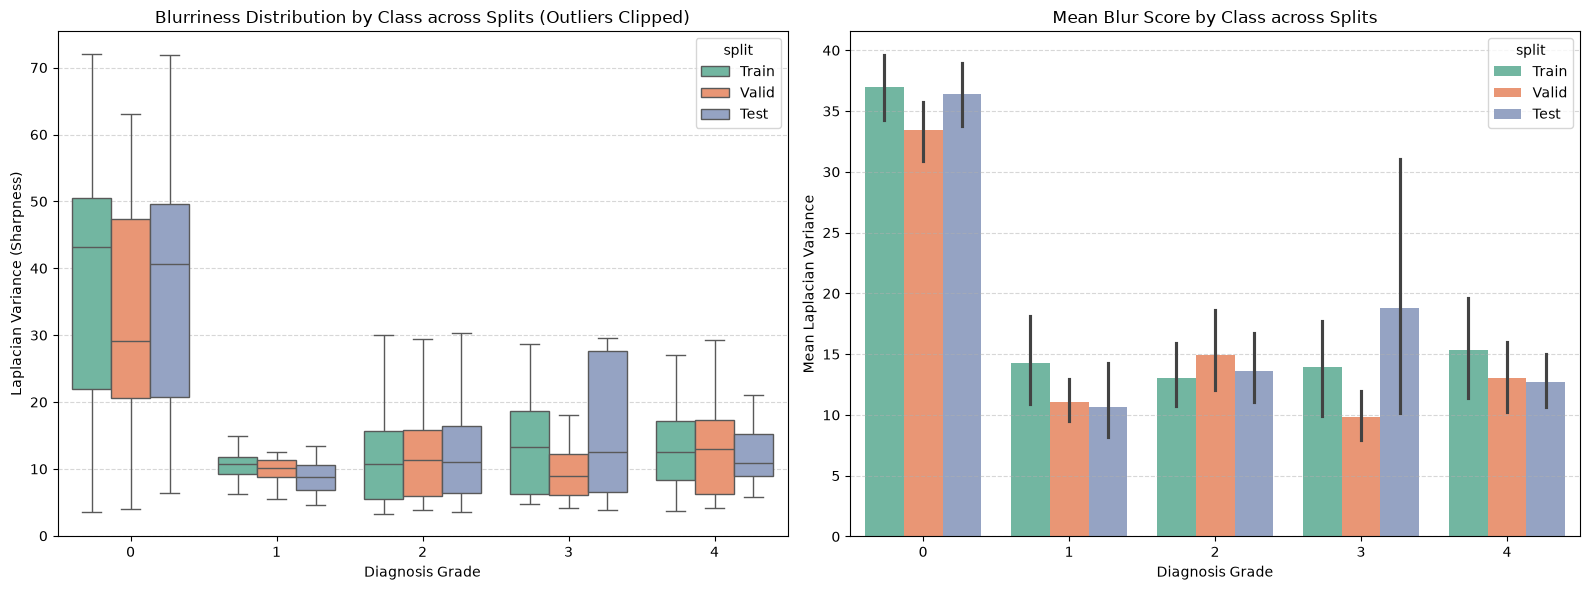

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

train_blur_df = get_blur_data(df_clean, train_images_dir, split_name="Train", n_samples=300)
valid_blur_df = get_blur_data(valid_df, valid_images_dir, split_name="Valid", n_samples=300)
test_blur_df  = get_blur_data(test_df,  test_images_dir,  split_name="Test",  n_samples=300)

all_blur_df = pd.concat([train_blur_df, valid_blur_df, test_blur_df], ignore_index=True)

print("--- Mean Blur Score per Class across Splits ---")
print(all_blur_df.groupby(["split", "diagnosis"])["blur"].mean().unstack(level=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=all_blur_df, x="diagnosis", y="blur", hue="split",
    palette="Set2", showfliers=False, ax=axes[0]
)
axes[0].set_title("Blurriness Distribution by Class across Splits (Outliers Clipped)")
axes[0].set_xlabel("Diagnosis Grade")
axes[0].set_ylabel("Laplacian Variance (Sharpness)")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

sns.barplot(
    data=all_blur_df, x="diagnosis", y="blur", hue="split",
    palette="Set2", errorbar=("ci", 95), ax=axes[1]
)
axes[1].set_title("Mean Blur Score by Class across Splits")
axes[1].set_xlabel("Diagnosis Grade")
axes[1].set_ylabel("Mean Laplacian Variance")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
save_figure(fig, "./outputs/figures/blur_by_class.png")
plt.show()

Observation:
Grade 0 images are consistently sharper (~2.5x higher Laplacian variance) than all diseased classes across train/valid/test. This is likely linked to diabetic cataracts causing lens haze in more advanced cases, but could also reflect equipment/protocol differences. Flagged for review during Grad-CAM interpretability — model should not rely on overall image haze as a shortcut for severity.

Hypothesis: Grade 0 looks yellow than rest grades which look a little reddish  

In [38]:
import cv2
def compute_mean_channels(img_path):
    img = cv2.imread(img_path)  
    b, g, r = cv2.mean(img)[:3]
    return r, g, b

sample_df2 = df_clean.sample(300, random_state=42)
color_data = []
for img_id, grade in zip(sample_df2['id_code'], sample_df2['diagnosis']):
    img_path = os.path.join(train_images_dir, img_id + ".png")
    r, g, b = compute_mean_channels(img_path)
    color_data.append({'id_code': img_id, 'diagnosis': grade, 'R': r, 'G': g, 'B': b})

color_df = pd.DataFrame(color_data)
print(color_df.groupby('diagnosis')[['R','G','B']].mean().round(2))

                R      G      B
diagnosis                      
0          101.94  54.48  17.07
1          119.51  57.48  14.52
2          105.81  57.78  23.88
3           94.76  51.17  18.39
4          106.36  56.95  19.31


Result of Hypothesis Testing : Initial visual inspection suggested a color difference between grade 0 and diseased classes. Quantitative per-channel analysis (mean R/G/B across 300 samples) did not show a consistent trend — R:G ratio remained ~1.8-2.1 across all classes. Concluded this was likely sample-size-driven visual bias rather than a true confound.